In [1]:
import numpy as np
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Load Model

In [19]:
import sys
sys.path.insert(0, '../../../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
teacher_model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
teacher_model.set_use_module_grafting(False)
teacher_model.set_use_scc_status(False)

In [27]:
outputs = teacher_model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.6582, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [28]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
teacher_model.to(device)

device

device(type='cuda')

### Load Trained Weights

In [29]:
load_path = '../../../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
teacher_model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [31]:
load_graft_path = '../../../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [32]:
from merge_helper import apply_layer_tracking_to_model

In [33]:
model = apply_layer_tracking_to_model(model, graft_state['layer_track'])

In [38]:
model.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [39]:
from train_eval_func import eval_loop

In [40]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8700980392156863, 'f1': 0.9084628670120898}

In [37]:
eval_loop(teacher_model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

# 5. Pruning FF

In [41]:
from structure_prune_helper import register_importance_masks, remove_importance_masks

In [42]:
register_importance_masks(model, device, register_heads=False, register_ffn=True)

  Layer 0: Registered masks (3072 neurons)
  Layer 1: Registered masks (6144 neurons)
  Layer 2: Registered masks (3072 neurons)
  Layer 3: Registered masks (3072 neurons)
  Layer 4: Registered masks (3072 neurons)
  Layer 5: Registered masks (6144 neurons)
  Layer 6: Registered masks (12288 neurons)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0): BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [43]:
from structure_prune_helper import masks_setGrad, iterativeMaskTrain

In [44]:
num_att_mask = int(12 * 12 * 0.1)
num_att_mask

14

In [45]:
num_int_mask = int(model.bert.encoder.layer[0].intermediate.dense.weight.shape[0] * 12 * 0.1)
num_int_mask

3686

In [46]:
recovery_epochs=3
patience=3
alpha=0.3
temperature=7

In [47]:
mask_history = iterativeMaskTrain(
    model, train_dataloader, val_dataloader, device, task_name, max_batches=200, mask_head=False, mask_ffn=True, 
    num_att_mask=num_att_mask, num_int_mask=num_int_mask, num_round=10, recovery_epochs=recovery_epochs,
    recovery_lr=1e-5, patience=patience, teacher_model=teacher_model,
    temp_save_path=f'../recovery/{task_name}-{len(model.bert.encoder.layer)}.pt'
)

Total Number of FFN Neurons: 36864
Evaluating Original Performance
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085
Threshold: 0.009084628670120899

--> Round: 0


Computing importance (FFN only): 100%|██████████| 115/115 [00:24<00:00,  4.72it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 33178, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3070 (99.93%)
Layer: 1, total: 6144, Remain: 6143 (99.98%)
Layer: 2, total: 3072, Remain: 3072 (100.0%)
Layer: 3, total: 3072, Remain: 3072 (100.0%)
Layer: 4, total: 3072, Remain: 3069 (99.9%)
Layer: 5, total: 6144, Remain: 6137 (99.89%)
Layer: 6, total: 12288, Remain: 8615 (70.11%)
  Metrics:
      accuracy: 0.8701
    ★ f1: 0.9085

--> Round: 1


Computing importance (FFN only): 100%|██████████| 115/115 [00:24<00:00,  4.74it/s]



Masking 3686 / 36864 neurons (10.0%)
Remaining FFN Neurons: 29492, Total FFN Neurons: 36864
FFN Neuron Mask Remaining Stats:
Layer: 0, total: 3072, Remain: 3069 (99.9%)
Layer: 1, total: 6144, Remain: 6139 (99.92%)
Layer: 2, total: 3072, Remain: 3071 (99.97%)
Layer: 3, total: 3072, Remain: 3070 (99.93%)
Layer: 4, total: 3072, Remain: 3061 (99.64%)
Layer: 5, total: 6144, Remain: 6108 (99.41%)
Layer: 6, total: 12288, Remain: 4974 (40.48%)
  Metrics:
      accuracy: 0.8676
    ★ f1: 0.9069

--> Round: 2


...

Training:  67%|██████▋   | 230/345 [01:25<00:34,  3.36it/s]

✓ Saved checkpoint (best loss: 1.2270)

<----------------- Epoch 2 ----------------->
Loss: 1.54, Training Metrics:
  accuracy: 0.8400
  f1: 0.8868
Validation Loss: 1.23, Validation Metrics:
  accuracy: 0.7647
  f1: 0.8457
Elapsed Time: 37.982 sec


Training: 100%|██████████| 345/345 [02:17<00:00,  2.51it/s]


<----------------- Epoch 3 ----------------->
Loss: 1.19, Training Metrics:
  accuracy: 0.8757
  f1: 0.9104
Validation Loss: 1.4, Validation Metrics:
  accuracy: 0.7598
  f1: 0.8444
Elapsed Time: 37.7049 sec

Total Training Time: 137.29 sec
Chosen Primary Metric: f1
Best Metric Run: 0.8457

  → Loading best checkpoint...


  ✓ Cleaned up temporary checkpoint


In [41]:
mask_history.keys()

dict_keys(['head_mask_remaining', 'head_mask_state', 'int_mask_remaining', 'int_mask_state', 'effected_metric'])

In [44]:
len(mask_history['effected_metric'])

10

In [42]:
mask_history['effected_metric']

[{'effected_eval_metric': {'accuracy': 0.8651960784313726,
   'f1': 0.9078726968174204}},
 {'effected_eval_metric': {'accuracy': 0.8676470588235294,
   'f1': 0.9093959731543624}},
 {'effected_eval_metric': {'accuracy': 0.8676470588235294,
   'f1': 0.9087837837837838}},
 {'effected_eval_metric': {'accuracy': 0.8651960784313726,
   'f1': 0.9066213921901528}},
 {'effected_eval_metric': {'accuracy': 0.8627450980392157,
   'f1': 0.9041095890410958}},
 {'effected_eval_metric': {'accuracy': 0.8553921568627451,
   'f1': 0.8984509466437177},
  'trained_eval_metric': {'accuracy': 0.8529411764705882,
   'f1': 0.9006622516556292}},
 {'effected_eval_metric': {'accuracy': 0.8308823529411765,
   'f1': 0.8874388254486134},
  'trained_eval_metric': {'accuracy': 0.8651960784313726,
   'f1': 0.907563025210084}},
 {'effected_eval_metric': {'accuracy': 0.8284313725490197,
   'f1': 0.8863636363636364},
  'trained_eval_metric': {'accuracy': 0.8529411764705882,
   'f1': 0.8958333333333334}},
 {'effected_eval_

In [43]:
mask_history['int_mask_remaining']

[33178, 29492, 25806, 22120, 18434, 14748, 11062, 7376, 3690, 4]

In [46]:
n_layer = len(model.bert.encoder.layer)

In [49]:
torch.save(mask_history, f'./weights/{task_name}_{n_layer}_hist.pt')

Figure saved to pruning_progression.png


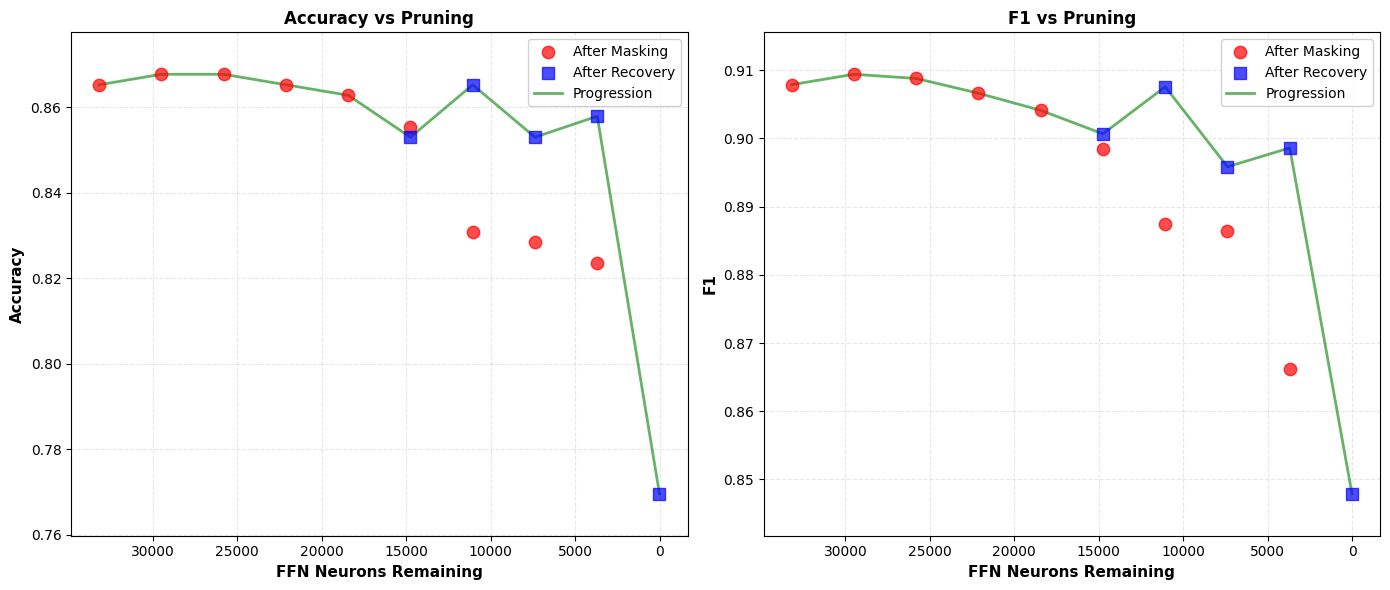

Figure saved to pruning_comparison.png


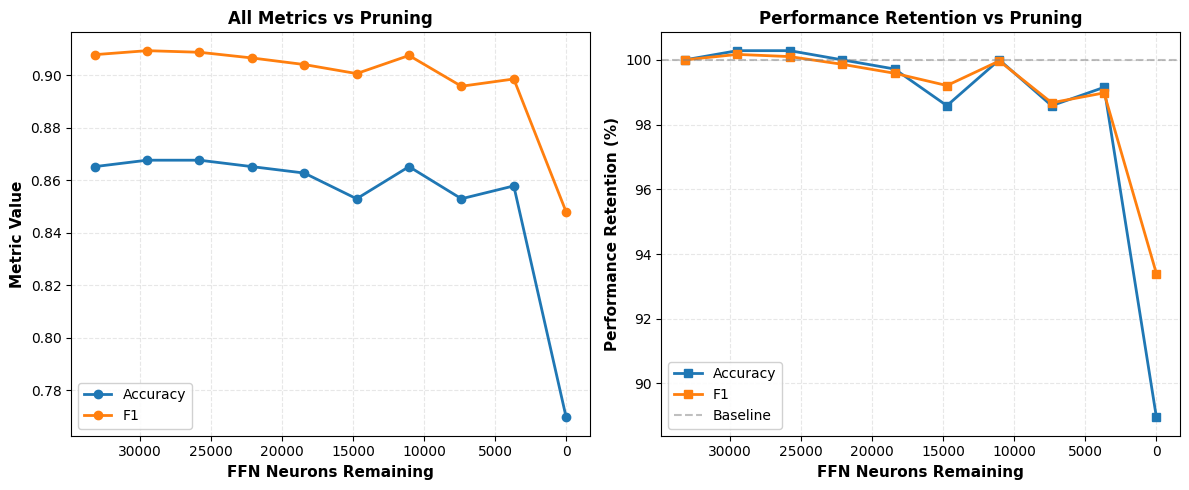


PRUNING PROGRESSION SUMMARY
Initial FFN Neurons: 33,178

--- Round 0 ---
Neurons Remaining: 33,178 (100.0%)
  After Masking:
    accuracy: 0.8652
    f1: 0.9079

--- Round 1 ---
Neurons Remaining: 29,492 (88.9%)
  After Masking:
    accuracy: 0.8676
    f1: 0.9094

--- Round 2 ---
Neurons Remaining: 25,806 (77.8%)
  After Masking:
    accuracy: 0.8676
    f1: 0.9088

--- Round 3 ---
Neurons Remaining: 22,120 (66.7%)
  After Masking:
    accuracy: 0.8652
    f1: 0.9066

--- Round 4 ---
Neurons Remaining: 18,434 (55.6%)
  After Masking:
    accuracy: 0.8627
    f1: 0.9041

--- Round 5 ---
Neurons Remaining: 14,748 (44.5%)
  After Masking:
    accuracy: 0.8554
    f1: 0.8985
  After Recovery Training:
    accuracy: 0.8529
    f1: 0.9007
  Recovery Improvement:
    accuracy: -0.0025
    f1: +0.0022

--- Round 6 ---
Neurons Remaining: 11,062 (33.3%)
  After Masking:
    accuracy: 0.8309
    f1: 0.8874
  After Recovery Training:
    accuracy: 0.8652
    f1: 0.9076
  Recovery Improvement:
  

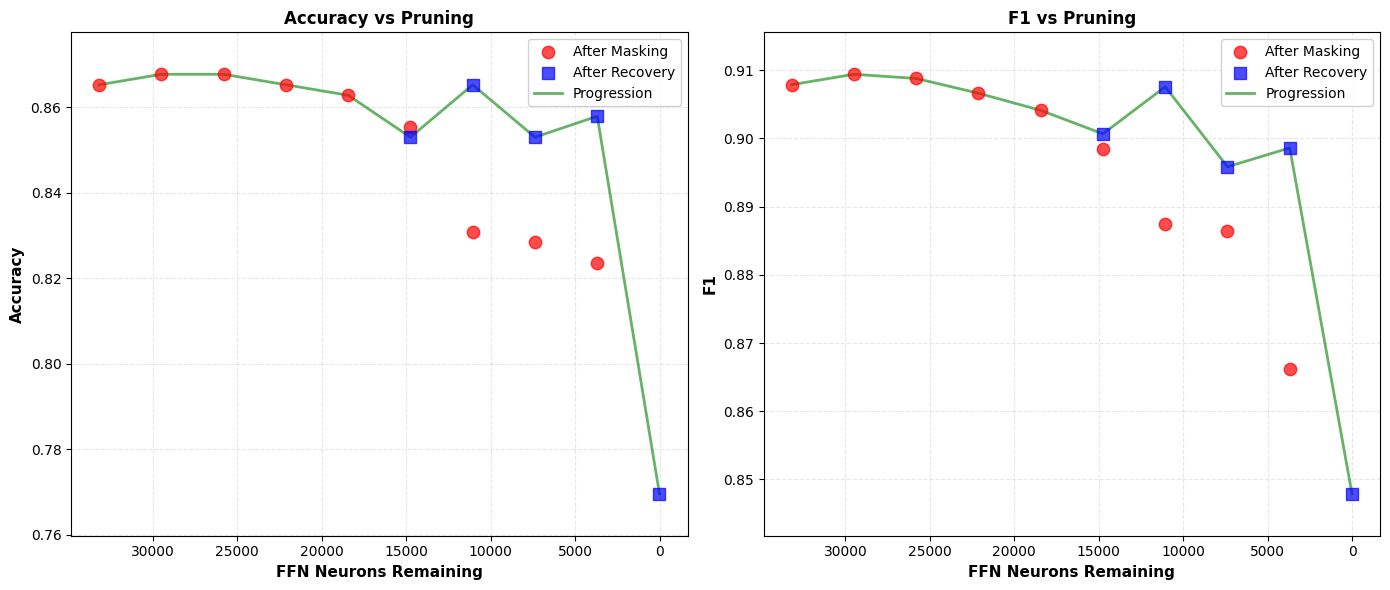

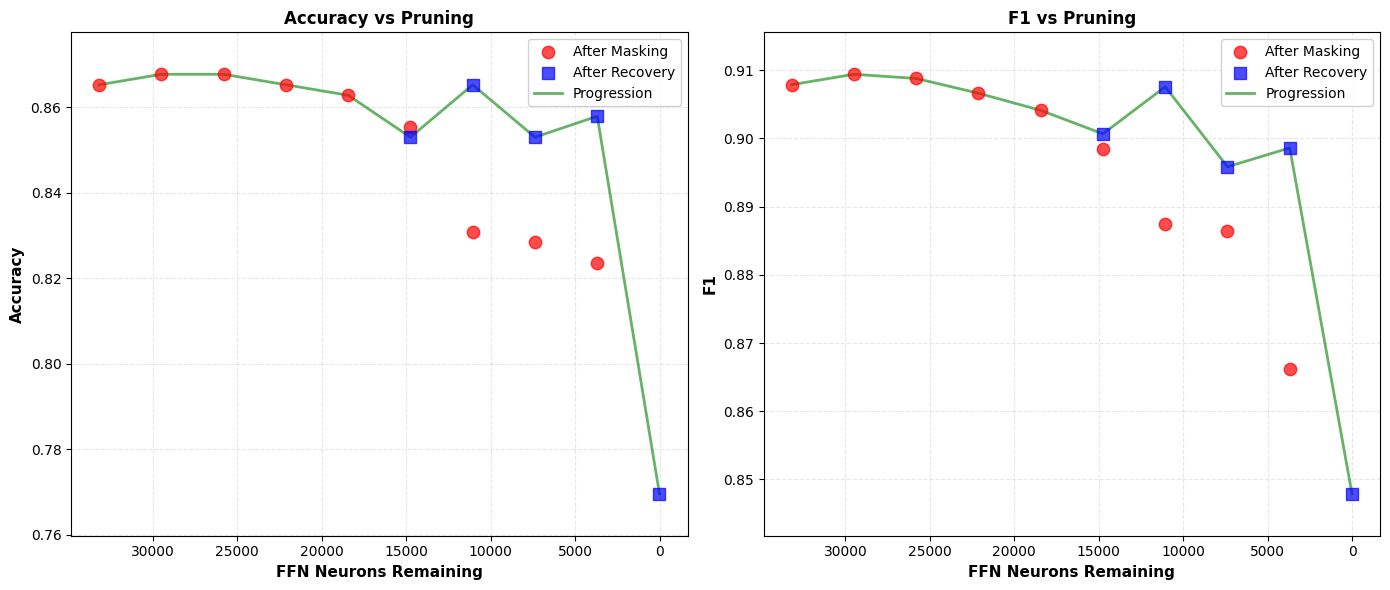

In [45]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pruning_progression(mask_history, target_metric='accuracy', 
                             figsize=(14, 6), save_path=None):
    """
    Plot pruning progression showing performance vs remaining neurons.
    
    Args:
        mask_history: Dict with 'effected_metric' and 'int_mask_remaining'
        target_metric: Primary metric to plot (e.g., 'accuracy', 'f1', 'pearson')
        figsize: Figure size tuple
        save_path: Path to save figure (optional)
    """
    # Extract data
    metrics_data = mask_history['effected_metric']
    neurons_remaining = mask_history['int_mask_remaining']
    
    # Collect all available metric names
    all_metric_names = set()
    for entry in metrics_data:
        if 'effected_eval_metric' in entry:
            all_metric_names.update(entry['effected_eval_metric'].keys())
    
    all_metric_names = sorted(list(all_metric_names))
    
    # Determine number of subplots needed
    n_metrics = len(all_metric_names)
    n_cols = min(3, n_metrics)  # Max 3 columns
    n_rows = (n_metrics + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    
    # Plot each metric
    for metric_idx, metric_name in enumerate(all_metric_names):
        ax = axes[metric_idx]
        
        # Extract metric values
        effected_values = []
        trained_values = []
        x_effected = []
        x_trained = []
        
        for round_idx, (entry, n_neurons) in enumerate(zip(metrics_data, neurons_remaining)):
            # Effected (immediately after masking)
            if 'effected_eval_metric' in entry and metric_name in entry['effected_eval_metric']:
                effected_values.append(entry['effected_eval_metric'][metric_name])
                x_effected.append(n_neurons)
            
            # Trained (after recovery training)
            if 'trained_eval_metric' in entry and metric_name in entry['trained_eval_metric']:
                trained_values.append(entry['trained_eval_metric'][metric_name])
                x_trained.append(n_neurons)
        
        # Plot effected points (dots)
        ax.scatter(x_effected, effected_values, 
                  color='red', marker='o', s=80, 
                  label='After Masking', zorder=3, alpha=0.7)
        
        # Plot trained points (if they exist)
        if trained_values:
            ax.scatter(x_trained, trained_values, 
                      color='blue', marker='s', s=80, 
                      label='After Recovery', zorder=3, alpha=0.7)
        
        # Connect points with lines
        # Strategy: Use trained value if it exists, otherwise use effected value
        connected_x = []
        connected_y = []
        
        for round_idx, (entry, n_neurons) in enumerate(zip(metrics_data, neurons_remaining)):
            # Prefer trained metric, fall back to effected
            if 'trained_eval_metric' in entry and metric_name in entry['trained_eval_metric']:
                connected_y.append(entry['trained_eval_metric'][metric_name])
            elif 'effected_eval_metric' in entry and metric_name in entry['effected_eval_metric']:
                connected_y.append(entry['effected_eval_metric'][metric_name])
            else:
                continue
            
            connected_x.append(n_neurons)
        
        # Draw connecting line
        if connected_x:
            ax.plot(connected_x, connected_y, 
                   color='green', linewidth=2, alpha=0.6, 
                   label='Progression', zorder=2)
        
        # Formatting
        ax.set_xlabel('FFN Neurons Remaining', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric_name.capitalize(), fontsize=11, fontweight='bold')
        ax.set_title(f'{metric_name.capitalize()} vs Pruning', 
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best', framealpha=0.9)
        
        # Invert x-axis (more neurons on left, fewer on right)
        ax.invert_xaxis()
        
        # Set y-axis limits with some padding
        if connected_y:
            y_min, y_max = min(connected_y), max(connected_y)
            y_range = y_max - y_min
            ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
    
    # Hide extra subplots
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig


def plot_pruning_comparison(mask_history, figsize=(12, 5), save_path=None):
    """
    Alternative visualization: side-by-side comparison of all metrics.
    
    Args:
        mask_history: Dict with 'effected_metric' and 'int_mask_remaining'
        figsize: Figure size tuple
        save_path: Path to save figure (optional)
    """
    metrics_data = mask_history['effected_metric']
    neurons_remaining = mask_history['int_mask_remaining']
    
    # Collect metric names
    all_metric_names = set()
    for entry in metrics_data:
        if 'effected_eval_metric' in entry:
            all_metric_names.update(entry['effected_eval_metric'].keys())
    all_metric_names = sorted(list(all_metric_names))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Left plot: All metrics on same axis (normalized)
    for metric_name in all_metric_names:
        connected_x = []
        connected_y = []
        
        for entry, n_neurons in zip(metrics_data, neurons_remaining):
            if 'trained_eval_metric' in entry and metric_name in entry['trained_eval_metric']:
                connected_y.append(entry['trained_eval_metric'][metric_name])
            elif 'effected_eval_metric' in entry and metric_name in entry['effected_eval_metric']:
                connected_y.append(entry['effected_eval_metric'][metric_name])
            else:
                continue
            connected_x.append(n_neurons)
        
        if connected_x:
            ax1.plot(connected_x, connected_y, marker='o', linewidth=2, 
                    label=metric_name.capitalize(), markersize=6)
    
    ax1.set_xlabel('FFN Neurons Remaining', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Metric Value', fontsize=11, fontweight='bold')
    ax1.set_title('All Metrics vs Pruning', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='best', framealpha=0.9)
    ax1.invert_xaxis()
    
    # Right plot: Performance retention (as percentage of original)
    for metric_name in all_metric_names:
        connected_x = []
        retention = []
        
        original_value = None
        
        for idx, (entry, n_neurons) in enumerate(zip(metrics_data, neurons_remaining)):
            if 'trained_eval_metric' in entry and metric_name in entry['trained_eval_metric']:
                value = entry['trained_eval_metric'][metric_name]
            elif 'effected_eval_metric' in entry and metric_name in entry['effected_eval_metric']:
                value = entry['effected_eval_metric'][metric_name]
            else:
                continue
            
            # First value is baseline
            if original_value is None:
                original_value = value
            
            retention.append(100 * value / original_value if original_value != 0 else 100)
            connected_x.append(n_neurons)
        
        if connected_x:
            ax2.plot(connected_x, retention, marker='s', linewidth=2,
                    label=metric_name.capitalize(), markersize=6)
    
    ax2.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Baseline')
    ax2.set_xlabel('FFN Neurons Remaining', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Performance Retention (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Performance Retention vs Pruning', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(loc='best', framealpha=0.9)
    ax2.invert_xaxis()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig


def print_pruning_summary(mask_history):
    """
    Print a text summary of pruning progression.
    """
    metrics_data = mask_history['effected_metric']
    neurons_remaining = mask_history['int_mask_remaining']
    
    print("\n" + "="*80)
    print("PRUNING PROGRESSION SUMMARY")
    print("="*80)
    
    # Get initial neuron count
    if neurons_remaining:
        initial_neurons = neurons_remaining[0]
        print(f"Initial FFN Neurons: {initial_neurons:,}")
    
    for round_idx, (entry, n_neurons) in enumerate(zip(metrics_data, neurons_remaining)):
        print(f"\n--- Round {round_idx} ---")
        print(f"Neurons Remaining: {n_neurons:,} ({100*n_neurons/initial_neurons:.1f}%)")
        
        # Print effected metrics
        if 'effected_eval_metric' in entry:
            print("  After Masking:")
            for metric_name, value in entry['effected_eval_metric'].items():
                print(f"    {metric_name}: {value:.4f}")
        
        # Print trained metrics
        if 'trained_eval_metric' in entry:
            print("  After Recovery Training:")
            for metric_name, value in entry['trained_eval_metric'].items():
                print(f"    {metric_name}: {value:.4f}")
            
            # Show improvement from recovery
            if 'effected_eval_metric' in entry:
                print("  Recovery Improvement:")
                for metric_name in entry['trained_eval_metric'].keys():
                    if metric_name in entry['effected_eval_metric']:
                        before = entry['effected_eval_metric'][metric_name]
                        after = entry['trained_eval_metric'][metric_name]
                        delta = after - before
                        print(f"    {metric_name}: {delta:+.4f}")
    
    print("\n" + "="*80)


# Usage examples:

# 1. Plot all metrics
plot_pruning_progression(mask_history, save_path='pruning_progression.png')

# 2. Plot comparison view
plot_pruning_comparison(mask_history, save_path='pruning_comparison.png')

# 3. Print text summary
print_pruning_summary(mask_history)

# 4. Plot specific metric only
plot_pruning_progression(mask_history, target_metric='f1')

In [50]:
int_mask = []
for i in range(12):
    int_mask.append(model.bert.encoder.layer[i].int_mask_param.tolist())

In [51]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.7696078431372549, 'f1': 0.8478964401294499}

In [52]:
eval_loop(teacher_model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

In [53]:
def prune_int_dim(model, int_mask):
    """ This method shows how to prune head (remove heads weights) based on
        the head importance scores as described in Michel et al. (http://arxiv.org/abs/1905.10650)
    """
    
    original_num_params = sum(p.numel() for p in model.parameters())
    
    keep_dims_dict = {}
    for layer in range(len(int_mask)):
        keep_dims = []
        for index, value in enumerate(int_mask[layer]):
            if value == 1:
                keep_dims.append(index)
        keep_dims_dict[layer] = keep_dims
    model.prune_int_dims(keep_dims_dict)
    
    pruned_num_params = sum(p.numel() for p in model.parameters())
    
    print("Pruning, original num of params:  %.2e, after pruning %.2e (%.1f percents)" % 
          (original_num_params, pruned_num_params, pruned_num_params / original_num_params * 100))

In [54]:
prune_int_dim(model, int_mask)

/usr/local/lib/python3.10/dist-packages/torch/nn/init.py:582: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Pruning, original num of params:  1.10e+08, after pruning 5.29e+07 (48.3 percents)


In [51]:
remove_importance_masks(model)

✓ Removed head and FFN masks


In [52]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8602941176470589, 'f1': 0.902229845626072}